# Exploratory Data Analysis — Xente Credit Risk Dataset

**Project:** Bati Bank Credit Scoring Model  
**Task:** 2 — Exploratory Data Analysis  
**Dataset:** Xente eCommerce transaction data  

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13

DATA_PATH = '/home/code0053/personal/credit-scoring-model/data/raw/data.csv'
df = pd.read_csv(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loaded: 95,662 rows × 16 columns


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


---
## 1. Data Overview

In [4]:
print('=== Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Unique Values per Column ===')
print(df.nunique().sort_values())

=== Shape ===
Rows: 95,662  |  Columns: 16

=== Data Types ===
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object

=== Unique Values per Column ===
CountryCode                 1
CurrencyCode                1
FraudResult                 2
ChannelId                   4
PricingStrategy             4
ProviderId                  6
ProductCategory             9
ProductId                  23
Value                    1517
Amount                   1676
SubscriptionId           3627
AccountId                3633
CustomerId       

In [5]:
# Parse timestamp
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

print('Transaction date range:')
print(f"  From : {df['TransactionStartTime'].min()}")
print(f"  To   : {df['TransactionStartTime'].max()}")
print(f"  Span : {(df['TransactionStartTime'].max() - df['TransactionStartTime'].min()).days} days")

Transaction date range:
  From : 2018-11-15 02:18:49+00:00
  To   : 2019-02-13 10:01:28+00:00
  Span : 90 days


In [3]:
print(f"Unique customers  : {df['CustomerId'].nunique():,}")
print(f"Unique accounts   : {df['AccountId'].nunique():,}")
print(f"Unique products   : {df['ProductId'].nunique():,}")
print(f"Product categories: {df['ProductCategory'].nunique()}")
print(f"Channels          : {df['ChannelId'].nunique()}")
print(f"Providers         : {df['ProviderId'].nunique()}")
print(f"Fraud rate        : {df['FraudResult'].mean():.4%}")

Unique customers  : 3,742
Unique accounts   : 3,633
Unique products   : 23
Product categories: 9
Channels          : 4
Providers         : 6
Fraud rate        : 0.2018%


---
## 2. Summary Statistics

In [ ]:
df.describe(include='all').T

In [6]:
# Numerical summary with skewness and kurtosis
num_cols = ['Amount', 'Value']
stats = df[num_cols].describe().T
stats['skewness'] = df[num_cols].skew()
stats['kurtosis'] = df[num_cols].kurt()
print(stats.round(2))

          count     mean        std        min    25%     50%     75%  \
Amount  95662.0  6717.85  123306.80 -1000000.0  -50.0  1000.0  2800.0   
Value   95662.0  9900.58  123122.09        2.0  275.0  1000.0  5000.0   

              max  skewness  kurtosis  
Amount  9880000.0     51.10   3363.13  
Value   9880000.0     51.29   3378.07  


---
## 3. Distribution of Numerical Features

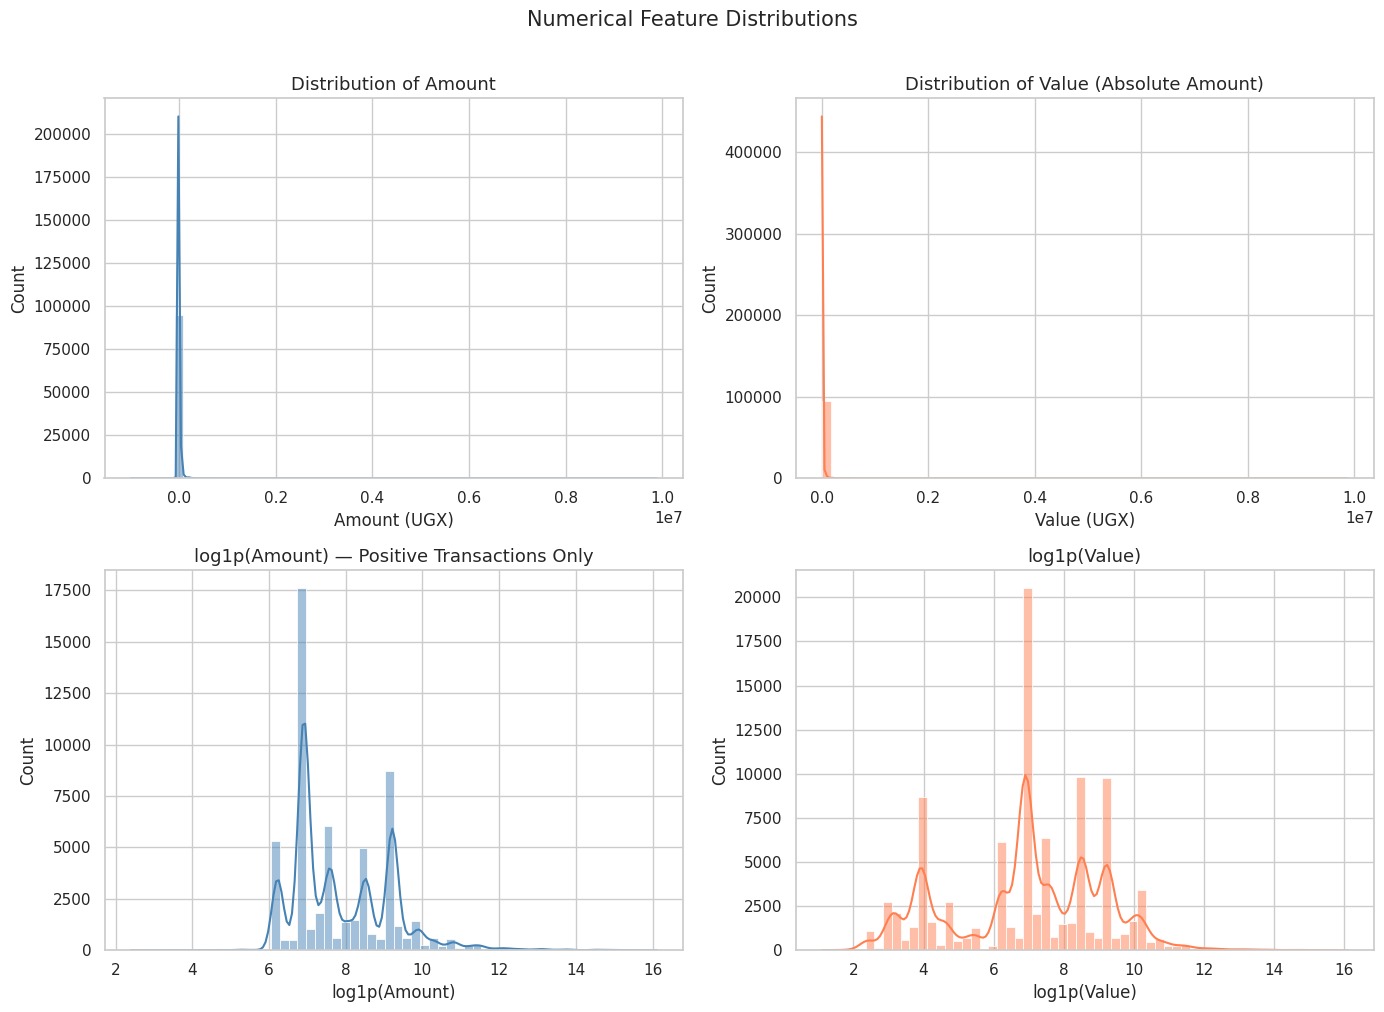

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution
sns.histplot(df['Amount'], bins=60, ax=axes[0, 0], color='steelblue', kde=True)
axes[0, 0].set_title('Distribution of Amount')
axes[0, 0].set_xlabel('Amount (UGX)')

# Value distribution
sns.histplot(df['Value'], bins=60, ax=axes[0, 1], color='coral', kde=True)
axes[0, 1].set_title('Distribution of Value (Absolute Amount)')
axes[0, 1].set_xlabel('Value (UGX)')

# Log-transformed Amount (positive only)
pos_amount = df[df['Amount'] > 0]['Amount']
sns.histplot(np.log1p(pos_amount), bins=60, ax=axes[1, 0], color='steelblue', kde=True)
axes[1, 0].set_title('log1p(Amount) — Positive Transactions Only')
axes[1, 0].set_xlabel('log1p(Amount)')

# Log-transformed Value
sns.histplot(np.log1p(df['Value']), bins=60, ax=axes[1, 1], color='coral', kde=True)
axes[1, 1].set_title('log1p(Value)')
axes[1, 1].set_xlabel('log1p(Value)')

plt.suptitle('Numerical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# Debit vs Credit split
debit  = (df['Amount'] > 0).sum()
credit = (df['Amount'] < 0).sum()
zero   = (df['Amount'] == 0).sum()

print(f'Debit transactions  (Amount > 0): {debit:,}  ({debit/len(df):.1%})')
print(f'Credit transactions (Amount < 0): {credit:,}  ({credit/len(df):.1%})')
print(f'Zero transactions   (Amount = 0): {zero:,}  ({zero/len(df):.1%})')

Debit transactions  (Amount > 0): 57,473  (60.1%)
Credit transactions (Amount < 0): 38,189  (39.9%)
Zero transactions   (Amount = 0): 0  (0.0%)


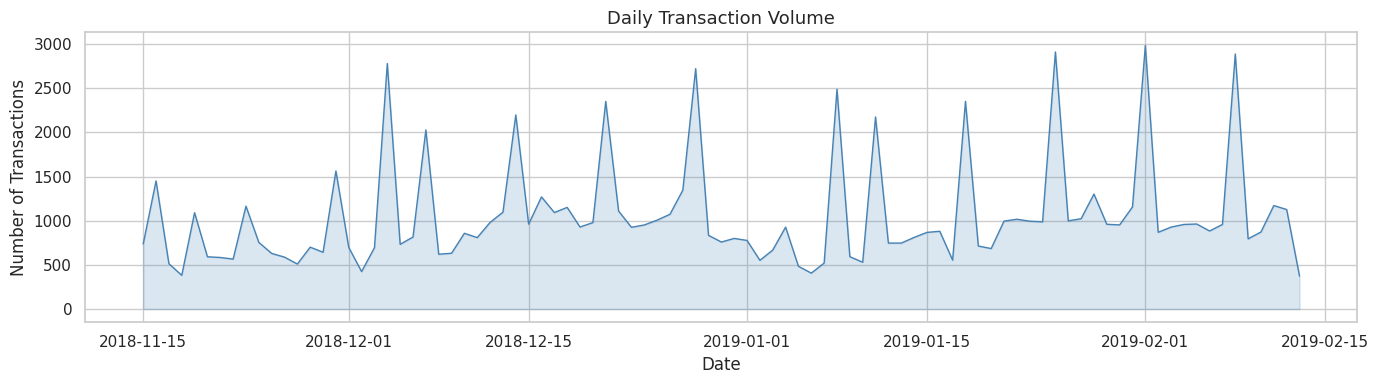

In [9]:
# Transactions over time
df['date'] = df['TransactionStartTime'].dt.date
daily = df.groupby('date').size().reset_index(name='count')

plt.figure(figsize=(14, 4))
plt.plot(daily['date'], daily['count'], color='steelblue', linewidth=1)
plt.fill_between(daily['date'], daily['count'], alpha=0.2, color='steelblue')
plt.title('Daily Transaction Volume')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

---
## 4. Distribution of Categorical Features

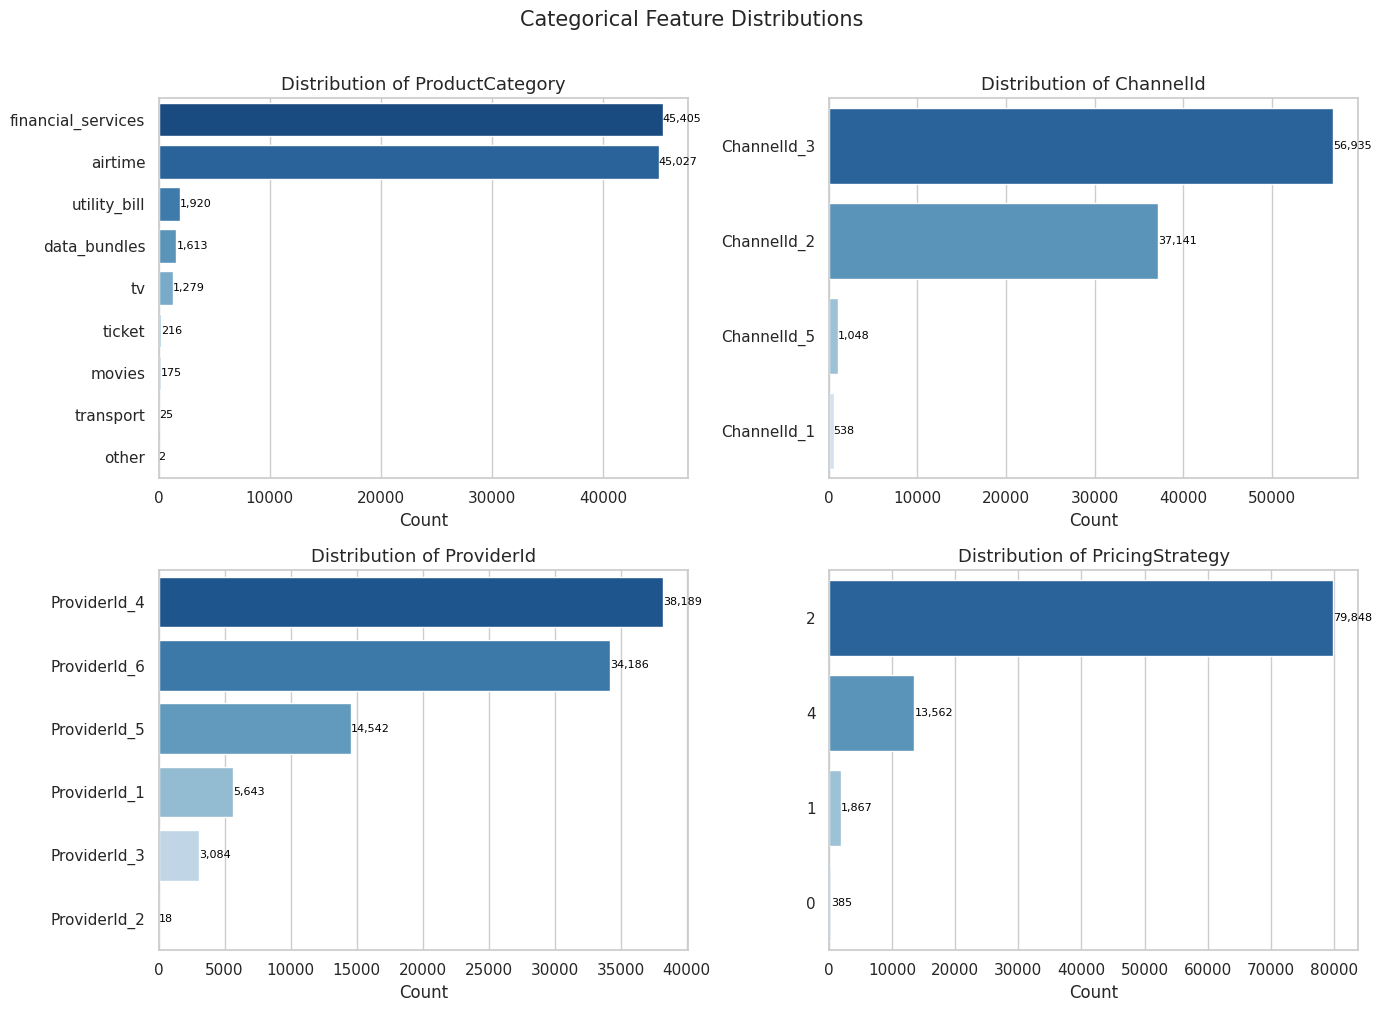

In [10]:
cat_cols = ['ProductCategory', 'ChannelId', 'ProviderId', 'PricingStrategy']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    counts = df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax,
                palette='Blues_r', orient='h')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Count')
    ax.set_ylabel('')
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width()):,}',
                    (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='left', va='center', fontsize=8, color='black')

plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

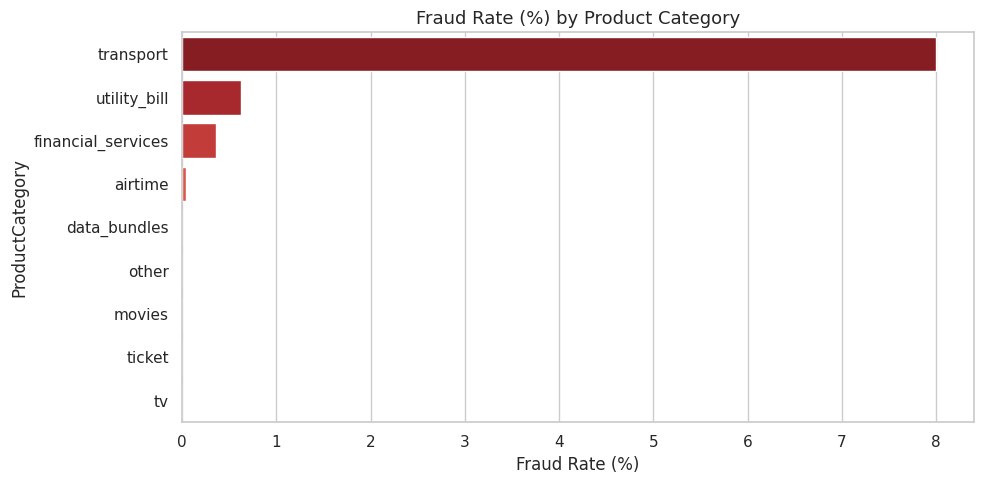

                    fraud_rate  fraud_count  total
ProductCategory                                   
transport             0.080000            2     25
utility_bill          0.006250           12   1920
financial_services    0.003546          161  45405
airtime               0.000400           18  45027
data_bundles          0.000000            0   1613
other                 0.000000            0      2
movies                0.000000            0    175
ticket                0.000000            0    216
tv                    0.000000            0   1279


In [11]:
# Fraud rate by product category
fraud_by_cat = (df.groupby('ProductCategory')['FraudResult']
                  .agg(['mean', 'sum', 'count'])
                  .rename(columns={'mean': 'fraud_rate', 'sum': 'fraud_count', 'count': 'total'})
                  .sort_values('fraud_rate', ascending=False))

plt.figure(figsize=(10, 5))
sns.barplot(x=fraud_by_cat['fraud_rate'] * 100, y=fraud_by_cat.index,
            palette='Reds_r', orient='h')
plt.title('Fraud Rate (%) by Product Category')
plt.xlabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

print(fraud_by_cat)

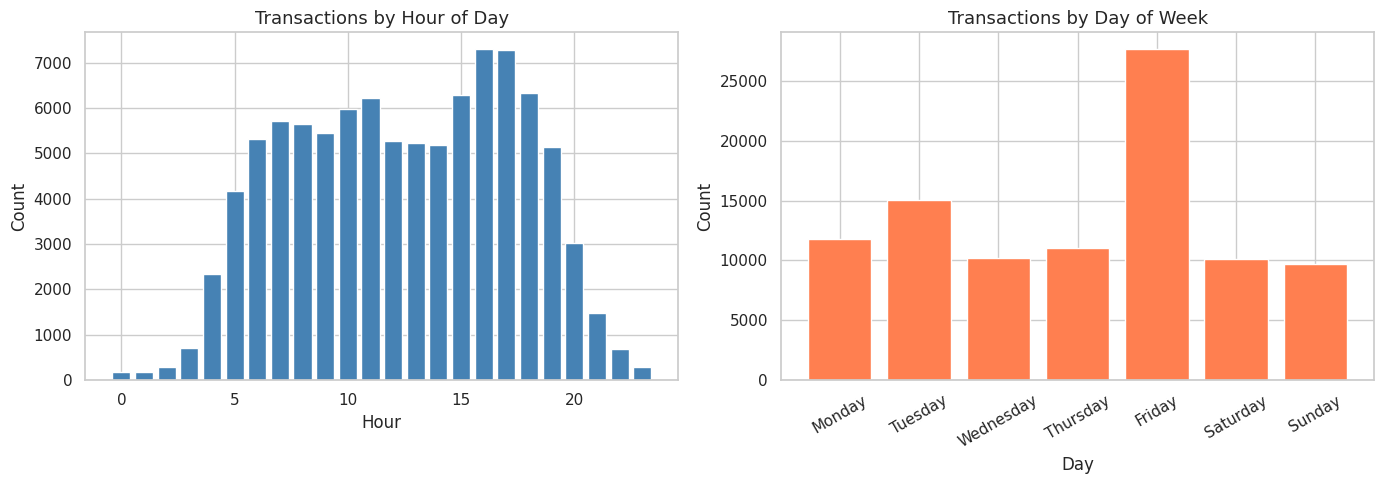

In [12]:
# Transactions by hour of day
df['hour'] = df['TransactionStartTime'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = df.groupby('hour').size()
axes[0].bar(hourly.index, hourly.values, color='steelblue')
axes[0].set_title('Transactions by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

dow = df['TransactionStartTime'].dt.day_name().value_counts()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = dow.reindex(day_order)
axes[1].bar(dow.index, dow.values, color='coral')
axes[1].set_title('Transactions by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## 5. Correlation Analysis

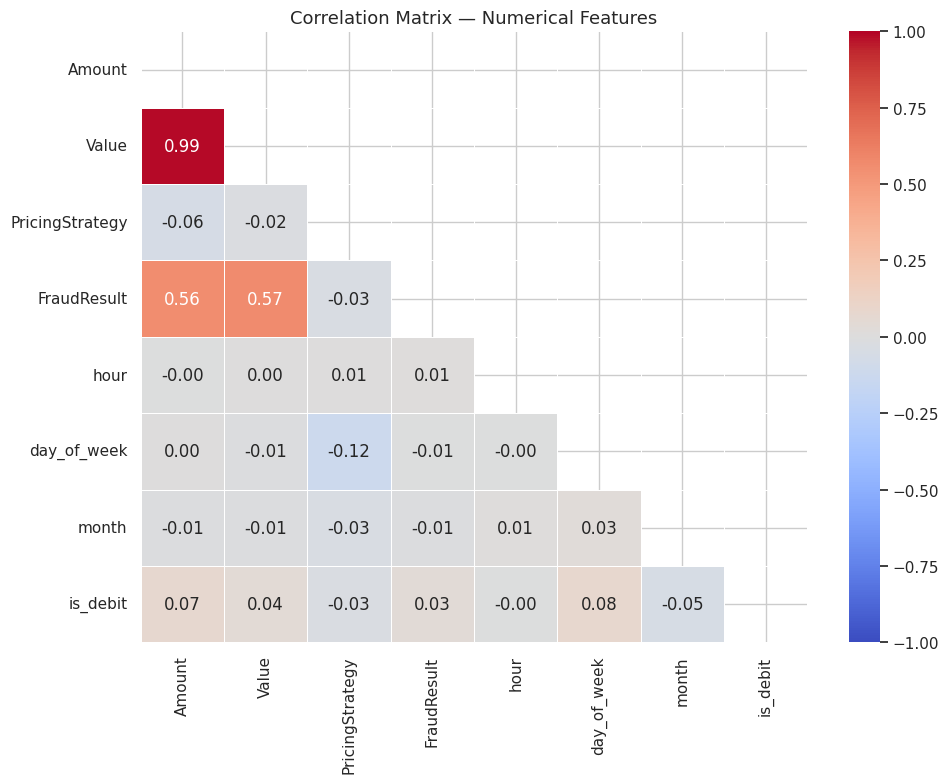

In [13]:
# Encode categoricals for correlation
df_corr = df.copy()
df_corr['hour'] = df_corr['TransactionStartTime'].dt.hour
df_corr['day_of_week'] = df_corr['TransactionStartTime'].dt.dayofweek
df_corr['month'] = df_corr['TransactionStartTime'].dt.month
df_corr['is_debit'] = (df_corr['Amount'] > 0).astype(int)

num_features = ['Amount', 'Value', 'PricingStrategy', 'FraudResult',
                'hour', 'day_of_week', 'month', 'is_debit']

corr_matrix = df_corr[num_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

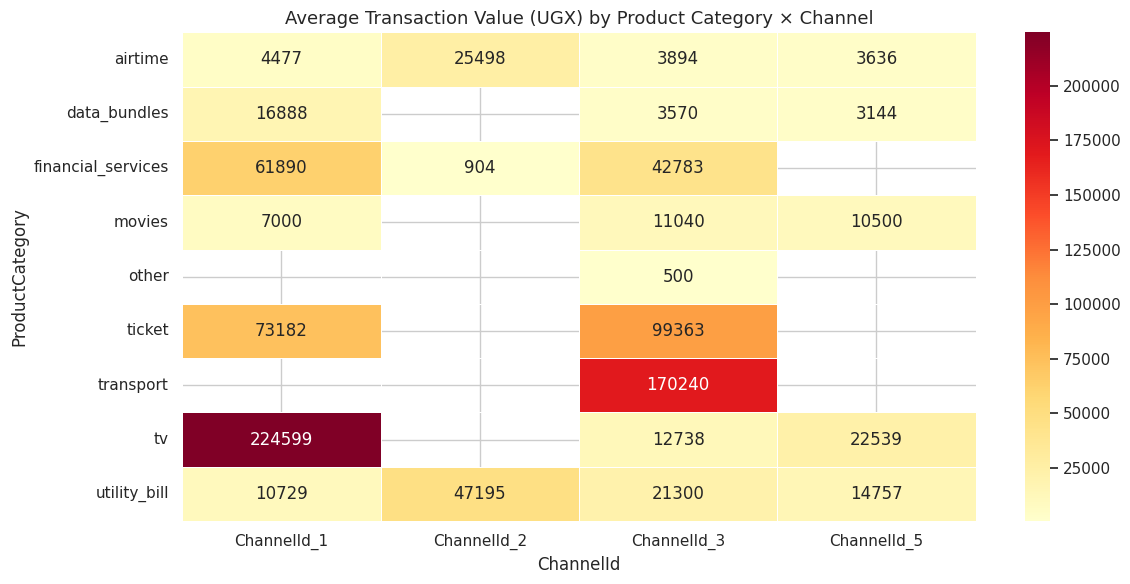

In [14]:
# Average transaction value by channel and category
pivot = df.groupby(['ProductCategory', 'ChannelId'])['Value'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Transaction Value (UGX) by Product Category × Channel')
plt.tight_layout()
plt.show()

---
## 6. Missing Value Analysis

In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)

print(missing_df)
print(f'\nColumns with missing values: {(missing > 0).sum()}')

                      missing_count  missing_pct
TransactionId                     0          0.0
BatchId                           0          0.0
AccountId                         0          0.0
SubscriptionId                    0          0.0
CustomerId                        0          0.0
CurrencyCode                      0          0.0
CountryCode                       0          0.0
ProviderId                        0          0.0
ProductId                         0          0.0
ProductCategory                   0          0.0
ChannelId                         0          0.0
Amount                            0          0.0
Value                             0          0.0
TransactionStartTime              0          0.0
PricingStrategy                   0          0.0
FraudResult                       0          0.0
date                              0          0.0
hour                              0          0.0

Columns with missing values: 0


In [16]:
if (missing > 0).any():
    plt.figure(figsize=(10, 4))
    cols_with_missing = missing_df[missing_df['missing_count'] > 0]
    sns.barplot(x=cols_with_missing['missing_pct'], y=cols_with_missing.index,
                palette='Reds_r', orient='h')
    plt.title('Missing Values (%)')
    plt.xlabel('Missing %')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the dataset.')

No missing values found in the dataset.


---
## 7. Outlier Detection

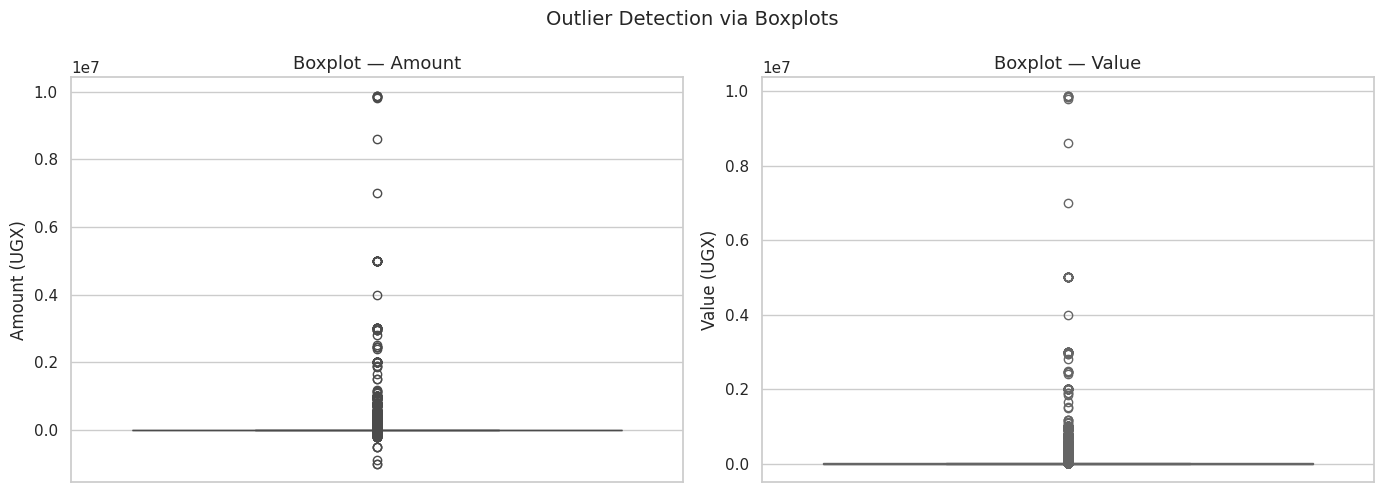

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(y=df['Amount'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot — Amount')
axes[0].set_ylabel('Amount (UGX)')

sns.boxplot(y=df['Value'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot — Value')
axes[1].set_ylabel('Value (UGX)')

plt.suptitle('Outlier Detection via Boxplots', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# IQR-based outlier counts
for col in ['Amount', 'Value']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: Q1={Q1:,.0f}, Q3={Q3:,.0f}, IQR={IQR:,.0f}, '
          f'bounds=[{lower:,.0f}, {upper:,.0f}], outliers={n_out:,} ({n_out/len(df):.2%})')

Amount: Q1=-50, Q3=2,800, IQR=2,850, bounds=[-4,325, 7,075], outliers=24,441 (25.55%)
Value: Q1=275, Q3=5,000, IQR=4,725, bounds=[-6,812, 12,088], outliers=9,021 (9.43%)


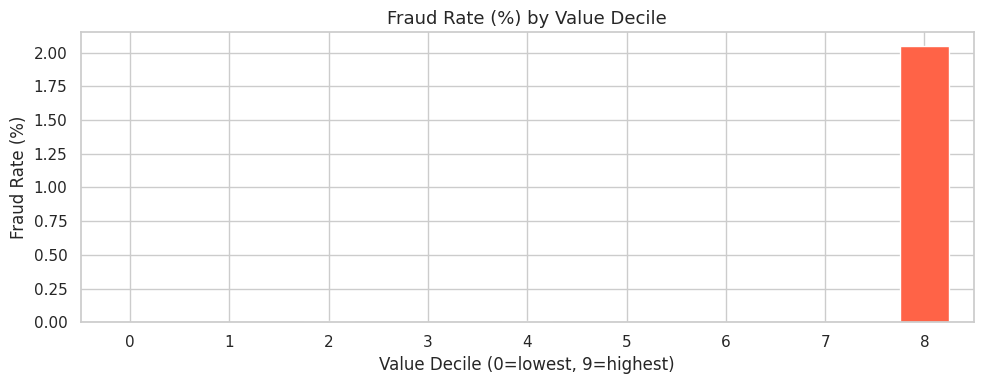

In [19]:
# Outlier profile: are large transactions more likely to be fraudulent?
df['value_percentile'] = pd.qcut(df['Value'], q=10, labels=False, duplicates='drop')
fraud_by_percentile = df.groupby('value_percentile')['FraudResult'].mean() * 100

plt.figure(figsize=(10, 4))
fraud_by_percentile.plot(kind='bar', color='tomato')
plt.title('Fraud Rate (%) by Value Decile')
plt.xlabel('Value Decile (0=lowest, 9=highest)')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

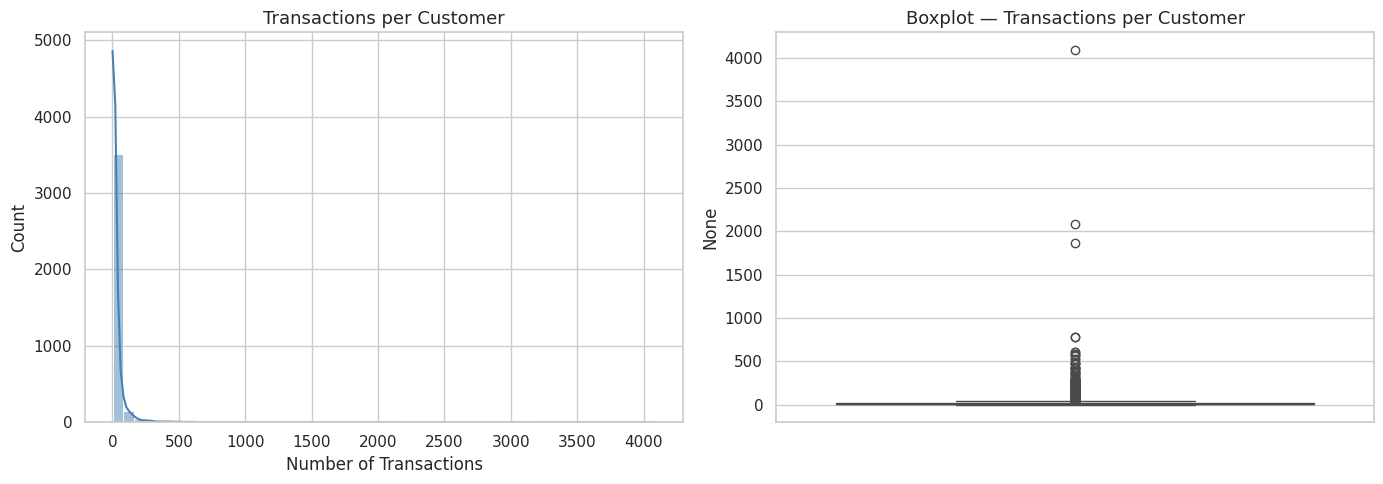

count    3742.000000
mean       25.564404
std        96.929602
min         1.000000
25%         2.000000
50%         7.000000
75%        20.000000
max      4091.000000
dtype: float64

Customers with only 1 transaction: 712 (19.0%)


In [20]:
# Transactions per customer distribution
txn_per_customer = df.groupby('CustomerId').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(txn_per_customer, bins=50, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Transactions per Customer')
axes[0].set_xlabel('Number of Transactions')

sns.boxplot(y=txn_per_customer, ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot — Transactions per Customer')

plt.tight_layout()
plt.show()

print(txn_per_customer.describe())
print(f'\nCustomers with only 1 transaction: {(txn_per_customer == 1).sum():,} '
      f'({(txn_per_customer == 1).mean():.1%})')

---
## 8. Key Insights Summary

The following are the top findings from the EDA, with direct implications for feature engineering and proxy variable design:

---

### Insight 1 — Highly Skewed Transaction Amounts Require Log Transformation
Both `Amount` and `Value` are heavily right-skewed with extreme outliers. A small number of very large transactions dominate the distribution. Log transformation (`log1p`) normalizes the distribution significantly and will be necessary before feeding these features into distance-based or linear models. IQR-based outlier capping should also be considered during preprocessing.

---

### Insight 2 — Strong Class Imbalance in Fraud Labels
The fraud rate is extremely low (~0.2%). This means `FraudResult` cannot serve as a direct credit risk proxy — it captures payment fraud, not default risk. Any model trained directly on this label would be degenerate. This reinforces the necessity of engineering a separate proxy target variable using RFM-based customer segmentation (Task 4).

---

### Insight 3 — Customer Engagement is Highly Uneven (RFM Signal)
Transaction frequency per customer is highly skewed: a large proportion of customers have very few transactions, while a small group are highly active. This behavioral disparity is exactly the signal RFM clustering will exploit. Low-frequency, low-monetary customers will form the high-risk cluster — the behavioral analog of credit disengagement.

---

### Insight 4 — Temporal Patterns Suggest Useful Time-Based Features
Transaction volume shows clear intraday and intraweek patterns. Hour of day and day of week show meaningful variation and should be extracted as features. The dataset spans a limited time window (late 2018–early 2019), which makes recency a meaningful RFM dimension — customers who last transacted early in the window are genuinely less engaged.

---

### Insight 5 — Product Category and Channel Are Predictive Dimensions
Fraud rates and average transaction values vary substantially across product categories and channels. `financial_services` and certain channels show higher fraud concentration. These categorical features carry predictive signal and should be encoded (one-hot or WoE) for model training. WoE encoding will be especially useful for logistic regression, as it monotonizes the relationship between each category and the target.